# DiaCausal — Causal Inference from First Principles

### A Clinical Decision Support System for Type-2 Diabetes
**B.Tech Major Project · RAG + Causal Inference · July–December 2026**

---

## What this notebook is, and why it exists next to the other one

There are two causal implementations in this repository and they do different jobs.

| | `causal_inference_implementation.py` | **this notebook** |
|---|---|---|
| Approach | DoWhy + EconML | hand-written NumPy |
| Lines for IPW | 1 (a library call) | 12 (visible arithmetic) |
| Answers "what is the effect?" | ✅ | ✅ |
| Answers "**show me how IPW works**" | ❌ points at a library | ✅ shows the formula running |
| Production-ready | closer to it | no — it is a teaching artifact |

Both are worth having. This is the one you can defend line by line.

## The rhythm of every act

> **plain-language question → the wrong answer → why it's wrong → the fix in ~15 lines → the number, printed next to the truth**

Nothing below is asserted. Every claim is a number you can watch appear.

## The ten acts

| Act | Question it answers |
|---|---|
| 0 | Why isn't an accurate predictor enough? |
| 1 | How could you ever know a causal estimate is *correct*? |
| 2 | What happens if you just compare the two groups? |
| 3 | Which variables must you adjust for — and which must you **not**? |
| 4 | Are you even *allowed* to answer? |
| 5 | How do you actually remove the confounding? |
| 6 | How do we know the hand-written code isn't subtly broken? |
| 7 | The average is +0.98 — what do I do with *this* patient? |
| 8 | Why does this project need **both** RAG and causal inference? |
| 9 | Where does all of this break? |

---
## Before you run: pick the right kernel

This notebook needs `dowhy`, `econml`, `networkx` and `scikit-learn`.

The older `DiaCausal_Causal_Inference.ipynb` in this repository targets a kernel called
**`myenv`**, and **that environment does not have dowhy, econml or networkx** — this notebook
will fail at Act 3 on it. Select the kernel whose interpreter has them (on the development
machine that is the Anaconda one). The cell below tells you immediately if you picked wrong,
rather than letting you find out fifteen cells later.

In [1]:
# ── Preflight: fail loudly and early, not halfway through Act 6 ──────────────
import importlib, sys

REQUIRED = {
    "numpy": "arrays", "pandas": "tables", "sklearn": "the base models",
    "scipy": "statistics", "matplotlib": "figures",
    "networkx": "the DAG (Act 3)", "dowhy": "the library cross-check (Act 6)",
    "econml": "the metalearner cross-check (Act 6)",
}
missing = []
for mod, why in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(f"{mod}  — needed for {why}")

print(f"interpreter: {sys.executable}")
if missing:
    print("\nMISSING DEPENDENCIES — you are probably on the wrong kernel:")
    for m in missing:
        print("   ·", m)
else:
    print("all dependencies present · this notebook will run start to finish")

interpreter: /opt/anaconda3/bin/python
all dependencies present · this notebook will run start to finish


In [2]:
# ── Setup ────────────────────────────────────────────────────────────────────
# MPLCONFIGDIR must be set before matplotlib is imported: the default config
# directory is not writable in every environment this project runs in, and
# matplotlib raises rather than degrading if it cannot write its font cache.
import os
os.environ.setdefault("MPLCONFIGDIR", os.environ.get("TMPDIR", "/tmp"))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 5),
                     "axes.grid": True, "grid.alpha": 0.25})

# One shared package. The notebook, the console script and the Streamlit app all
# import THESE functions — so a number shown here is produced by exactly the same
# code that produces it everywhere else. No format has its own copy of an
# estimator, which is the only way to keep three artifacts honest.
from causal_engine import (
    PALETTE, cdss, crosscheck, dag, data, diagnostics, estimators, evaluate,
    guardrails, pdf_text, rag_lite,
)

N_PATIENTS, SEED = 4000, 7
os.makedirs("figures", exist_ok=True)
print("causal_engine ready ·", f"n={N_PATIENTS}", f"seed={SEED}")

causal_engine ready · n=4000 seed=7


---
# ACT 0 — Prediction is not decision

> **The question:** why is a very accurate predictor still useless for choosing a drug?

Two sentences that sound similar and are not the same *kind* of claim at all:

| | |
|---|---|
| **PREDICTION** | "This patient's HbA1c will be 8.4% in six months." |
| **DECISION** | "This patient should be given SGLT2i rather than metformin." |

A predictive model — classifier, neural net, boosted tree — answers the first. It learns
patterns in data *as it was collected*. And here is the trap:

**In that data, the sickest patients received the strongest drugs.** So a predictor learns
`strong drug → bad outcome`. That is a perfectly real pattern, and exactly backwards as advice.

### The analogy that lands with anyone

> Hospitals that treat the sickest patients have the worst survival rates.
> **Are they the worst hospitals?**

Obviously not. But a model that only sees the correlation cannot tell the difference between
*"this treatment harms people"* and *"this treatment is given to people who were already
worse off."*

### Pearl's ladder of causation

| Rung | Question | Notation | Who lives here |
|---|---|---|---|
| 1. Seeing | What usually happens? | $P(Y \mid X)$ | almost all machine learning |
| 2. Doing | What if I intervene? | $P(Y \mid do(T))$ | **what a CDSS needs** |
| 3. Imagining | What *would have* happened? | $P(Y_t \mid T=t')$ | the counterfactual |

A CDSS stuck on rung 1 will confidently **withhold effective treatment from the patients who
need it most**. Everything below is about reaching rung 2 — and Act 1 reaches rung 3, but only
because we wrote both outcomes ourselves.

---
# ACT 1 — A world where we know the truth

> **The question:** how could you ever know your causal estimate is *correct*?

This is the question that sinks most causal projects at a viva, and it has a genuinely good
answer: **build the world yourself.**

We generate a synthetic cohort in which we *write* the drug's effect for every individual
patient. That gives us an answer key. Then we throw the answer key away, hand the estimators
only what a real hospital would have, and grade them.

Nobody can do this with real data — the true individual effect is unobservable, permanently,
for every patient who has ever lived. Which is exactly *why* a synthetic benchmark has to come
first: **if a method cannot recover an answer we planted ourselves, it has no business being
pointed at real patients.**

### The effect function we authored

$$\tau(x) \;=\; \underbrace{1.5}_{\text{base}} \;+\; \underbrace{0.035\,(\mathrm{BMI}-30)}_{\text{heavier patients benefit MORE}} \;-\; \underbrace{2.5\max\!\left(0,\tfrac{70-\mathrm{eGFR}}{25}\right)}_{\text{kidney function collapses the benefit}}$$

Both gradients are clinically real, not modelling convenience. SGLT2 inhibitors work by making
the kidney dump glucose into the urine — so a heavier patient loses more, and **a kidney that
has stopped filtering cannot deliver the mechanism at all.**

### The single most important design decision in this project

Below roughly **eGFR 55 the authored effect crosses zero** and the drug becomes actively worse
than metformin for glycaemic control.

That zero-crossing means the population average (+0.98, helpful) is the **wrong advice for a
real minority of patients**. So recovering the average is not enough, and a CDSS has something
to do that a summary statistic cannot.

In [3]:
cohort = data.generate_cohort(N_PATIENTS, scenario="strong", seed=SEED)
print(cohort.summary())
print()
print(f"patients genuinely HARMED by the drug : {(cohort.true_cate < 0).mean():.1%}")
print(f"true individual effects range         : {cohort.true_cate.min():+.2f} "
      f"to {cohort.true_cate.max():+.2f} HbA1c points")
print(f"spread of true effects (SD)           : {cohort.true_cate.std():.2f}")

scenario='strong'  n=4000  treated=1678 (42%)  TRUE ATE=+0.9800  naive=-0.8959  naive error=-1.8759

patients genuinely HARMED by the drug : 14.6%
true individual effects range         : -4.28 to +2.38 HbA1c points
spread of true effects (SD)           : 1.01


### The Fundamental Problem of Causal Inference, printed

Every patient has **two** potential outcomes: $Y_0$ (what happens on metformin) and $Y_1$ (what
happens on SGLT2i). The individual effect is $\tau_i = Y_1^{(i)} - Y_0^{(i)}$.

**Reality shows you exactly one of them, forever.**

The table below prints both columns — the only reason that is possible is that we are inside a
simulation. Read the `observed` column: it is $Y_1$ where `took_drug=1` and $Y_0$ where it is 0.
In a real hospital the other column is simply *absent*.

In [4]:
show = cohort.data.loc[:, ["patient_id", "bmi", "egfr", "treatment_sglt2i",
                           "y0", "y1", "true_cate", "hba1c_reduction"]].head(8).copy()
show.columns = ["id", "BMI", "eGFR", "took_drug", "Y0 (metformin)", "Y1 (SGLT2i)",
                "TRUE effect", "observed"]
display(show.round(2))

print("Y0, Y1 and TRUE effect are hidden from every estimator from this point on.")
print("The estimators see only:", data.COVARIATES, "+ treatment + observed outcome.")

,id,BMI,eGFR,took_drug,Y0 (metformin),Y1 (SGLT2i),TRUE effect,observed
0,1,35.5,47.2,0,0.71,0.13,-0.59,0.71
1,2,37.4,62.8,1,-1.36,-0.33,1.04,-0.33
2,3,25.1,119.9,0,7.17,8.49,1.33,7.17
3,4,38.6,62.7,0,2.22,3.29,1.07,2.22
4,5,28.2,120.0,0,6.06,7.49,1.44,6.06
5,6,24.8,74.8,0,4.76,6.08,1.32,4.76
6,7,30.0,70.4,1,-0.58,0.92,1.50,0.92
7,8,22.2,102.0,0,3.52,4.75,1.23,3.52


Y0, Y1 and TRUE effect are hidden from every estimator from this point on.
The estimators see only: ['age', 'bmi', 'baseline_hba1c', 'egfr', 'has_cvd', 'has_ckd'] + treatment + observed outcome.


---
# ACT 2 — The naive answer, and the sign flip

> **The question:** what happens if you just compare the two groups?

The obvious thing to do:

$$\widehat{\text{ATE}}_{\text{naive}} = \underbrace{\bar{Y}_{T=1}}_{\text{mean among those who took the drug}} - \underbrace{\bar{Y}_{T=0}}_{\text{mean among those who did not}}$$

In [5]:
naive = estimators.naive_difference(cohort.Y, cohort.T)
truth = float(cohort.true_cate.mean())

print(f"naive answer   {naive.value:+.4f}")
print(f"TRUE answer    {truth:+.4f}")
print(f"error          {naive.value - truth:+.4f}"
      f"   ({abs(naive.value-truth)/abs(truth):.0%} wrong — and the SIGN is wrong)")

naive answer   -0.8959
TRUE answer    +0.9800
error          -1.8759   (191% wrong — and the SIGN is wrong)


### ⚠️ The naive comparison says the drug **harms** patients. The truth is that it **helps**.

A CDSS built on that number would withhold an effective drug from every patient who could
benefit from it. **This single result is the entire justification for the causal half of this
project.**

### Why it goes wrong — who actually got the drug?

The bias is not mysterious. It is visible directly in the data: the two groups were never
comparable in the first place.

In [6]:
display(data.confounding_table(cohort).round(2))

,Metformin (T=0),SGLT2i (T=1),difference,SMD,balanced?
age,55.83,60.41,4.58,0.40,NO
bmi,30.96,30.85,-0.11,-0.02,yes
baseline_hba1c,8.30,8.86,0.56,0.39,NO
egfr,78.76,70.08,-8.68,-0.45,NO
has_cvd,0.31,0.31,-0.00,-0.00,yes
has_ckd,0.04,0.10,0.06,0.23,NO
severity,-1.25,-0.06,1.19,0.75,NO


Sicker patients — **higher HbA1c, worse kidneys, older** — were preferentially given the newer
drug. They then did worse, *because they were sicker*, not because of the drug. The naive
comparison attributes their sickness to the treatment.

### Turn the confounding dial and watch the answer move

One parameter controls how strongly clinical severity drove prescribing. Nothing else changes —
**the drug's true effect is identical in all four rows.**

In [7]:
display(data.scenario_comparison(N_PATIENTS, seed=SEED).round(4))

,scenario,treated %,naive answer,TRUE answer,naive error,sign flipped?
0,rct,51.0,1.054,0.98,0.074,no
1,mild,47.6,0.461,0.98,-0.519,no
2,strong,41.9,-0.896,0.98,-1.876,YES — says the drug HARMS
3,hidden_confounder,45.7,-2.118,0.98,-3.098,YES — says the drug HARMS


Read that table top to bottom and the whole field is in it:

| Scenario | What happens | The lesson |
|---|---|---|
| `rct` | naive is **correct** | This is *why* randomised trials are the gold standard: random assignment destroys confounding by construction. |
| `mild` | naive drifts | Modest confounding already misleads you. |
| `strong` | naive **flips sign** | Correlation reverses the clinical conclusion. Causal methods hold. |
| `hidden_confounder` | **causal fails too** | The thing driving prescribing was never recorded. No amount of statistics recovers information that is not there. |

> **The last row matters as much as the third.** These methods are not magic. Act 9 returns to it.

---
# ACT 3 — Draw your assumptions before you compute anything

> **The question:** which variables should you adjust for — and which must you **not**?

The instinct is *"adjust for everything you measured."* That instinct is wrong, and wrong in two
different directions. A **DAG** — a drawing of what you believe causes what — is how you tell
them apart *before* writing any code.

### The three roles a variable can play

| Role | Shape | What it does | Adjust? |
|---|---|---|---|
| **Confounder** | `T ← C → Y` | causes both treatment and outcome; creates fake association | ✅ **must** |
| **Mediator** | `T → M → Y` | carries the real effect | ❌ **never** — you erase what you're measuring |
| **Collider** | `T → K ← Y` | is *caused by* both | ❌ **never** — you *create* a fake association |

A **backdoor path** is any path from treatment to outcome that starts with an arrow *into* the
treatment. Those are the leaks. Block every one of them and what remains is causal.

In [8]:
graph = dag.build_graph()
print(dag.path_report(graph))

Backdoor paths from Treatment to Outcome: 25

    Treatment  <-  Age  ->  BMI  ->  Outcome
    Treatment  <-  Age  ->  HbA1c_baseline  ->  Outcome
    Treatment  <-  Age  ->  Comorbidities  ->  Outcome
    Treatment  <-  Age  ->  Comorbidities  ->  eGFR  ->  Outcome
    Treatment  <-  Age  ->  Outcome
    Treatment  <-  BMI  ->  Age  ->  HbA1c_baseline  ->  Outcome
    Treatment  <-  BMI  ->  Age  ->  Comorbidities  ->  Outcome
    Treatment  <-  BMI  ->  Age  ->  Comorbidities  ->  eGFR  ->  Outcome
    Treatment  <-  BMI  ->  Age  ->  Outcome
    Treatment  <-  BMI  ->  Outcome
    Treatment  <-  HbA1c_baseline  ->  Age  ->  BMI  ->  Outcome
    Treatment  <-  HbA1c_baseline  ->  Age  ->  Comorbidities  ->  Outcome
    Treatment  <-  HbA1c_baseline  ->  Age  ->  Comorbidities  ->  eGFR  ->  Outcome
    Treatment  <-  HbA1c_baseline  ->  Age  ->  Outcome
    Treatment  <-  HbA1c_baseline  ->  Outcome
    Treatment  <-  Comorbidities  ->  Age  ->  BMI  ->  Outcome
    Treatment  <-  Co

In [9]:
display(dag.explain_adjustment(graph))

,variable,role,adjust?,why
0,Age,confounder,YES,causes BOTH treatment and outcome — leaves a backdoor open
1,BMI,confounder,YES,causes BOTH treatment and outcome — leaves a backdoor open
2,HbA1c_baseline,confounder,YES,causes BOTH treatment and outcome — leaves a backdoor open
3,Comorbidities,confounder,YES,causes BOTH treatment and outcome — leaves a backdoor open
4,eGFR,confounder,YES,causes BOTH treatment and outcome — leaves a backdoor open
5,Treatment,treatment,—,this is the exposure
6,Outcome,outcome,—,this is what we are measuring
7,Adherence,mediator,NO,carries part of the real effect — adjusting deletes it
8,AdverseEvents,descendant of treatment,NO,happens after treatment — cannot confound it
9,SevereHyperglycaemia,descendant of outcome,NO,happens after the outcome — cannot cause it


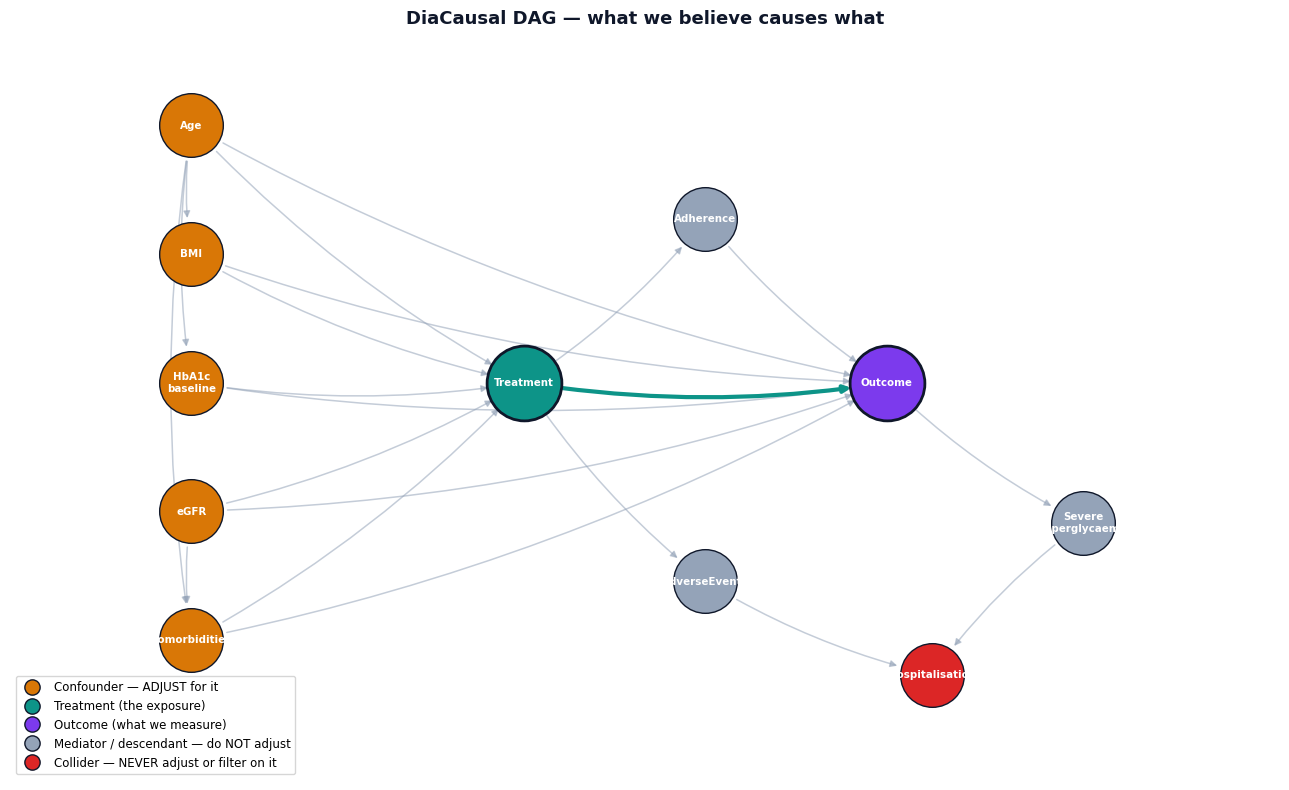

In [10]:
fig, ax = plt.subplots(figsize=(13, 8))
dag.draw_dag(graph, ax=ax, save_to="figures/nb_act3_dag.png")
plt.show()

### Now **demonstrate** the two mistakes, rather than just defining them

Most projects state that collider bias exists. Here is what it *does to the number*, measured on
our own cohort where we know the right answer.

In [11]:
display(dag.structural_mistakes_table(cohort).round(4))

,structural mistake,what we did,measured on,done right,done wrong,truth,damage
0,OMITTED CONFOUNDER,dropping baseline HbA1c,strong,0.8155,0.3520,0.98,0.4636
1,OVER-ADJUSTMENT,controlling for adherence (a mediator),strong,0.8155,0.6922,0.98,0.1233
2,COLLIDER BIAS,filtering on hospitalisation,rct,1.0543,0.9495,0.98,-0.0438


In [12]:
for demo in (dag.demo_collider_bias(cohort),
             dag.demo_over_adjustment(cohort),
             dag.demo_confounder_omission(cohort)):
    print(f"── {demo.name} " + "─" * (72 - len(demo.name)))
    print(f"   correct  {demo.correct:+.4f}      mistaken  {demo.mistaken:+.4f}"
          f"      truth  {demo.truth:+.4f}")
    print(f"   damage   {demo.damage:+.4f}")
    print()
    print("  ", demo.explanation.replace("\n", "\n   "))
    print()

── COLLIDER BIAS — filtering on hospitalisation ────────────────────────────
   correct  -0.8959      mistaken  -1.4205      truth  +0.9800
   damage   +0.5246

   Hospitalisation is caused by BOTH the drug (via side effects) and the outcome (via poor control). Restricting to one level of it opens a path between them that does not exist in the full population. Note that BOTH subgroups are wrong, in OPPOSITE directions, and neither equals the whole — the signature of a collider. More filtering, worse answer.

── OVER-ADJUSTMENT — controlling for adherence (a mediator) ────────────────
   correct  +0.8155      mistaken  +0.6922      truth  +0.9800
   damage   +0.1233

   Adherence is on the pathway Treatment -> Adherence -> Outcome. Adjusting for it holds fixed part of HOW the drug works, so part of the real effect is subtracted away. The estimate shrinks and looks just as confident.

── OMITTED CONFOUNDER — dropping baseline HbA1c ────────────────────────────
   correct  +0.8155      mi

> **Adjusting for a COLLIDER manufactures an association that does not exist.
> Adjusting for a MEDIATOR erases one that does.**
>
> Both of them look, from the outside, exactly like "controlling for more variables."

This is why the DAG comes *before* the code. There is no diagnostic that can rescue you from
having conditioned on the wrong thing — the number just comes out wrong and looks fine.

---
# ACT 4 — Are you even *allowed* to answer?

> **The question:** what has to be true about the data before any of this is valid?

Three assumptions. Two are checkable and this act checks them. The third is not checkable at
all — so we quantify **how badly it would have to fail** instead of asserting it holds.

| # | Assumption | Formally | Checkable? |
|---|---|---|---|
| 1 | **Positivity / overlap** | $0 < P(T{=}1 \mid X{=}x) < 1$ for all $x$ | ✅ yes |
| 2 | **Ignorability** | $(Y_0, Y_1) \perp T \mid X$ | ❌ **no** — the whole difficulty of the field |
| 3 | **SUTVA / consistency** | $Y = T Y_1 + (1-T) Y_0$, no interference | by design here |

### The propensity score

$$e(x) = P(T = 1 \mid X = x)$$

The probability *this* patient would have been prescribed the drug, given what we know about
them. Almost everything below is built on it.

In [13]:
prop = estimators.estimate_propensity(cohort.X, cohort.T, cross_fit=True)
print(f"propensity scores: min {prop.scores.min():.4f}   "
      f"median {np.median(prop.scores):.4f}   max {prop.scores.max():.4f}")
print(f"cross-fitted     : {prop.cross_fitted}   "
      f"(each patient's score comes from a model that never saw them)")
print(f"clipped to       : {prop.notes['clip']}   "
      f"({prop.notes['n_clipped']} scores clipped)")

propensity scores: min 0.0433   median 0.4056   max 0.9271
cross-fitted     : True   (each patient's score comes from a model that never saw them)
clipped to       : (0.01, 0.99)   (0 scores clipped)


## 1. POSITIVITY — the overlap check

If some kind of patient *always* got the drug, there is no untreated comparison for them. Not a
hard comparison — an **impossible** one.

treated propensity range   0.078 – 0.927
control propensity range   0.043 – 0.911
effective sample size      3245 of 4000
largest single weight      12.8

VERDICT: SATISFIED
Both groups span a common propensity range with no extreme weights. Every patient had a genuine chance of either drug, so a comparison is licensed.


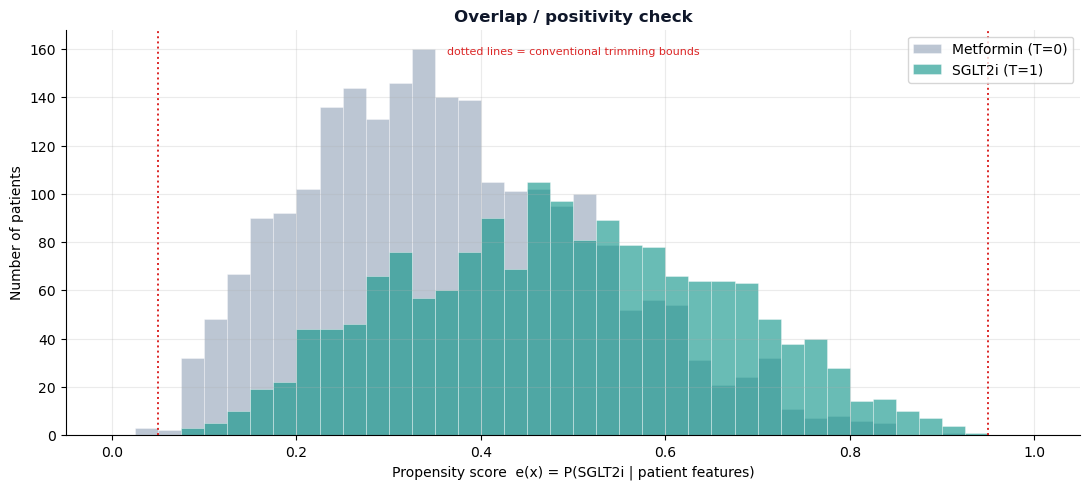

In [14]:
rep = diagnostics.overlap_report(prop.scores, cohort.T)
print(f"treated propensity range   {rep.min_treated:.3f} – {rep.max_treated:.3f}")
print(f"control propensity range   {rep.min_control:.3f} – {rep.max_control:.3f}")
print(f"effective sample size      {rep.effective_sample_size:.0f} of {len(cohort.T)}")
print(f"largest single weight      {rep.max_weight:.1f}")
print(f"\nVERDICT: {rep.verdict}")
print(rep.detail)

fig, ax = plt.subplots(figsize=(11, 5))
diagnostics.plot_overlap(prop.scores, cohort.T, ax=ax, save_to="figures/nb_act4_overlap.png")
plt.show()

### ... and the same check on a cohort where positivity is **broken**

Here a hard clinical rule (*"never prescribe below eGFR 60"*) means an entire region of patient
space contains **zero** treated patients.

In [15]:
broken = data.generate_cohort(N_PATIENTS, scenario="strong", seed=SEED,
                              violate_positivity=True)
bprop = estimators.estimate_propensity(broken.X, broken.T, cross_fit=True)
brep = diagnostics.overlap_report(bprop.scores, broken.T)
print(f"VERDICT: {brep.verdict}")
print(brep.detail)

trim = estimators.trim_by_overlap(bprop.scores, bounds=(0.1, 0.9),
                                  covariates=broken.X, covariate_names=data.COVARIATES)
print(f"\ntrimming to propensity 0.1–0.9 keeps {trim.fraction_kept:.1%} of patients "
      f"({trim.n_after} of {trim.n_before})")

# dropped_profile is a nested dict {covariate: {dropped_mean, kept_mean}} — the
# shape is deliberate (it is an audit record, not a display object), so build the
# comparison table here where we want to look at it.
profile = pd.DataFrame(trim.dropped_profile).T
profile["difference"] = profile["dropped_mean"] - profile["kept_mean"]
display(profile.round(2))

VERDICT: ACCEPTABLE with caution
251 patients sit in the tails. Consider trimming and report both the trimmed and untrimmed answers.

trimming to propensity 0.1–0.9 keeps 93.3% of patients (3731 of 4000)


,dropped_mean,kept_mean,difference
age,55.95,57.88,-1.93
bmi,30.94,30.91,0.03
baseline_hba1c,8.42,8.54,-0.13
egfr,37.23,77.85,-40.63
has_cvd,0.30,0.31,-0.02
has_ckd,0.93,0.00,0.93


The patients dropped are **not a random sample** — they are systematically the sickest. The
estimate that survives trimming is honest, but it is an estimate about a *different, healthier
population*. **Saying so is part of the result**, not a footnote to it.

## 2. BALANCE — did the weighting actually *work*?

Positivity says a comparison is possible. Balance checks whether the weights we are about to use
genuinely made the groups comparable.

$$\mathrm{SMD} = \frac{\bar{x}_{T=1} - \bar{x}_{T=0}}{\sqrt{(s_1^2 + s_0^2)/2}}$$

Convention: $|\mathrm{SMD}| < 0.1$ is balanced.

,covariate,SMD before,SMD after,improved?,balanced?
0,age,0.3970,0.0014,yes,yes
1,bmi,-0.0194,0.0083,yes,yes
2,baseline_hba1c,0.3908,0.0036,yes,yes
3,egfr,-0.4534,0.0024,yes,yes
4,has_cvd,-0.0021,0.0044,NO,yes
5,has_ckd,0.2256,-0.0040,yes,yes


imbalanced BEFORE weighting: 4 of 6
imbalanced AFTER  weighting: 0 of 6


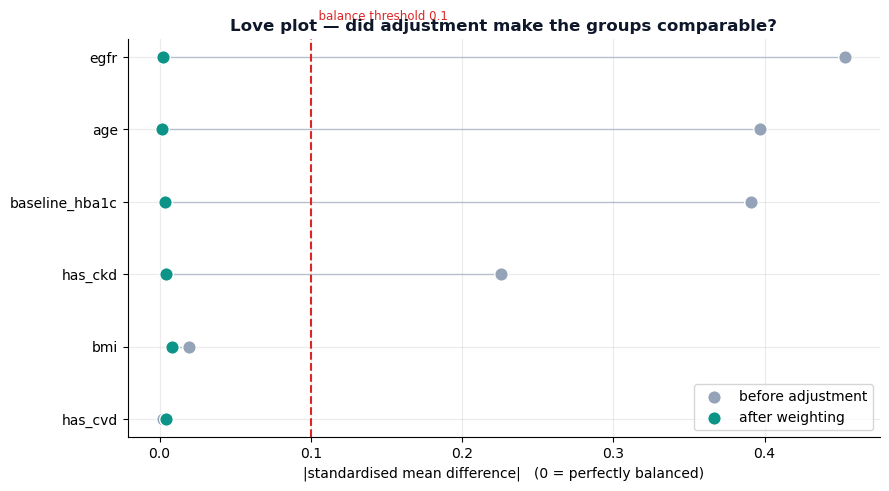

In [16]:
weights = np.where(cohort.T == 1, 1 / prop.scores, 1 / (1 - prop.scores))
bal = diagnostics.balance_table(cohort.X, cohort.T, data.COVARIATES, weights=weights)
display(bal.round(4))

print(f"imbalanced BEFORE weighting: {(bal['SMD before'].abs() > 0.1).sum()} of {len(bal)}")
print(f"imbalanced AFTER  weighting: {(bal['SMD after'].abs()  > 0.1).sum()} of {len(bal)}")

fig, ax = plt.subplots(figsize=(9, 5))
diagnostics.plot_love(bal, ax=ax, save_to="figures/nb_act4_love.png")
plt.show()

**This love plot is the single most persuasive diagnostic in the project.** It shows the
adjustment doing its job, variable by variable: age, HbA1c, eGFR and CKD all start badly
imbalanced and end within a whisker of zero.

## 3. IGNORABILITY — untestable, so quantify the vulnerability instead

You cannot test for a confounder you did not measure. What you **can** do is ask how strong one
would have to be to destroy your conclusion — the **E-value** (VanderWeele & Ding, 2017).

A large E-value means only an implausibly powerful hidden variable could overturn the finding.

In [17]:
aipw = estimators.aipw_ate(cohort.X, cohort.T, cohort.Y, cross_fit=True)
lo, hi = aipw.ci
ev = diagnostics.e_value(aipw.value, ci_low=lo, sd=float(cohort.Y.std()))

print(f"estimate {aipw.value:+.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
print(f"E-value (point estimate)  {ev.e_value:.2f}")
print(f"E-value (CI boundary)     {ev.e_value_ci:.2f}")
print()
print(ev.interpretation)

estimate +0.9786   95% CI [+0.9341, +1.0230]
E-value (point estimate)  2.16
E-value (CI boundary)     2.12

ROBUST. The hidden confounder would need to be about as strong as the strongest variable we measured. Possible, but it would have to be named.


### The move only a synthetic study can make

We *planted* a hidden confounder in the `hidden_confounder` scenario. So we can compare the
E-value's warning against the real thing — checking whether the sensitivity analysis is
calibrated, rather than trusting it.

In [18]:
hidden = data.generate_cohort(N_PATIENTS, scenario="hidden_confounder", seed=SEED)
print(diagnostics.evalue_verdict(hidden, ev))

E-value quoted            : 2.12
Actual confounder strength: 4.20   (treatment leg 4.20, outcome leg 4.42)

THE E-VALUE WAS RIGHT, AND WE SHOULD HAVE LISTENED.
    A confounder of strength >= 2.12 would erase this finding, and the one hiding in this data has strength 4.20. That is exactly what happened: every method returned the wrong sign, every balance check passed, and the E-value was the only diagnostic that pointed at the danger.


---
# ACT 5 — Four fixes, written by hand

> **The question:** how do you actually *remove* the confounding?

Four methods, each in under twenty lines of NumPy, each printed against the truth. They are not
four arbitrary alternatives — **each one fixes a specific weakness in the one before it.**

## FIX 1 — Stratification: compare like with like

Sort patients into buckets of similar treatment probability. Inside a bucket, who got the drug is
nearly arbitrary — so the naive comparison is valid *there*.

$$\widehat{\text{ATE}} = \sum_{s} \frac{n_s}{N}\Big(\bar{Y}_{T=1,s} - \bar{Y}_{T=0,s}\Big)$$

In [19]:
strat = estimators.stratified_effect(cohort.X, cohort.T, cohort.Y,
                                     n_strata=10, propensity=prop.scores)
print(f"estimate {strat.value:+.4f}   truth {truth:+.4f}   error {strat.value - truth:+.4f}")
print(f"strata skipped (no treated or no control patient in them): "
      f"{strat.notes['strata_skipped']}")
if strat.notes["warning"]:
    print(strat.notes["warning"])

# per_stratum is a list of dicts — one row per bucket, so you can see the
# within-bucket comparison that the weighted average is built from.
display(pd.DataFrame(strat.notes["per_stratum"]).round(3))

estimate +0.8934   truth +0.9800   error -0.0866
strata skipped (no treated or no control patient in them): 0


,stratum,n,effect,n_treated,n_control
0,0,400,1.141,62,338
1,1,400,1.469,104,296
2,2,400,1.386,121,279
3,3,400,1.358,118,282
4,4,400,1.166,140,260
5,5,400,1.079,178,222
6,6,400,0.985,194,206
7,7,400,0.689,217,183
8,8,400,0.351,246,154
9,9,400,-0.689,298,102


**Read the `effect` column down the table** — it is one of the most informative outputs in the
notebook, and it is not the point stratification was meant to make.

Stratum 0 holds the patients least likely to be prescribed the drug; stratum 9 the most likely.
The effect **falls steadily and turns negative in the last bucket.** That is not noise: patients
with a high propensity are the sicker, lower-eGFR patients, and low eGFR is precisely what stops
this drug working.

So the heterogeneity that Act 7 spends four metalearners recovering is already faintly visible
here, in ten lines of arithmetic. Note also the `n_treated`/`n_control` columns going in opposite
directions — that imbalance is the confounding itself, laid out bucket by bucket.

**Honest weakness:** the bucket count is a knob, and the answer moves with it. Too few buckets
and each still mixes dissimilar patients; too many and each holds too few patients to average.
Act 6 *measures* that trade-off rather than hiding it.

## FIX 2 — G-computation: model the outcome, then simulate both worlds

Fit one model of the outcome. Then ask it to predict **every** patient twice — once as if
treated, once as if not — and average the difference. You are simulating the two parallel worlds
you cannot observe.

$$\mu(x,t) = \mathbb{E}[Y \mid X=x, T=t] \qquad\Longrightarrow\qquad \widehat{\text{ATE}} = \frac{1}{N}\sum_i \big[\mu(x_i, 1) - \mu(x_i, 0)\big]$$

In [20]:
gcomp = estimators.g_computation(cohort.X, cohort.T, cohort.Y, n_bootstrap=100)
print(f"gradient boosting    {gcomp.value:+.4f}   error {gcomp.value - truth:+.4f}")

from sklearn.linear_model import LinearRegression
gcomp_lin = estimators.g_computation(cohort.X, cohort.T, cohort.Y, model=LinearRegression())
print(f"LINEAR outcome model {gcomp_lin.value:+.4f}   error {gcomp_lin.value - truth:+.4f}")

gradient boosting    +0.8155   error -0.1644
LINEAR outcome model +0.9624   error -0.0176


**Read those two numbers again, because they are the opposite way round from what you expect.**

The gradient booster is the more powerful model. The true effect really does contain a BMI
interaction and a kink at eGFR 70, which a straight line cannot represent. And yet the *linear*
model got closer to the truth.

That is not a bug, and it is not luck. Here is the cause, measured rather than asserted:

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# Which features does the outcome model actually spend its capacity on?
Xt = np.column_stack([cohort.X, cohort.T])
gb = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                               learning_rate=0.05, random_state=0).fit(Xt, cohort.Y)

names = list(data.COVARIATES) + ["TREATMENT"]
importance = (pd.Series(gb.feature_importances_, index=names)
                .sort_values(ascending=False).round(4))
print("feature importance inside the outcome model")
print(importance.to_string())
print()

# If shrinkage is the cause, then shrinking LESS should attenuate less.
relaxed = estimators.g_computation(
    cohort.X, cohort.T, cohort.Y, n_bootstrap=0,
    model=GradientBoostingRegressor(n_estimators=500, max_depth=5,
                                    learning_rate=0.30, random_state=0))
print(f"default GB (lr 0.05)   {gcomp.value:+.4f}   error {gcomp.value - truth:+.4f}")
print(f"relaxed GB (lr 0.30)   {relaxed.value:+.4f}   error {relaxed.value - truth:+.4f}")

feature importance inside the outcome model
egfr              0.4566
age               0.2521
baseline_hba1c    0.2468
TREATMENT         0.0436
bmi               0.0009
has_ckd           0.0000
has_cvd           0.0000

default GB (lr 0.05)   +0.8155   error -0.1644
relaxed GB (lr 0.30)   +0.9156   error -0.0644


**`TREATMENT` receives about 4% of the model's attention.** The other 96% goes to eGFR, age and
baseline HbA1c — because those drive the *level* of the outcome, and the level is where the
variance is. The treatment contrast is small by comparison, so a regularised learner treats it as
almost-noise and shrinks it toward zero. Hence the attenuation.

And the confirmation: **relaxing the shrinkage cuts the error roughly in half.** If the problem
were the model class being too rigid, loosening it would not help in that direction.

This has a name — **regularisation bias** — and removing it is the entire reason Chernozhukov et
al. (2018) invented double machine learning. Shrinkage applied to a *nuisance* quantity
(the outcome surface) leaks into the *estimand* (the treatment contrast).

The honest lesson is the reverse of the intuitive one:

> When your causal estimate is biased, do not reach for a more flexible model.
> Reach for an **estimator whose errors cancel**.

Which is exactly what FIX 5 does — AIPW uses this *same* gradient booster and lands within
0.002 of the truth. The improvement comes from the correction term, not from the model.

*(You will meet this mechanism once more in Act 7: the S-learner is the worst performer on the
CATE leaderboard, and this is why. `g_computation` appends `T` as one more feature, which makes it
an S-learner — so it inherits the same weakness.)*

G-computation's whole weight still rests on the outcome model being right. Which motivates the
next two fixes.

## FIX 3 — IPW: reweight the sample into a pseudo-randomised trial

If a patient had only a 20% chance of receiving the drug and received it anyway, they represent
about **five** such patients — so count them five times. Weighting every patient by
$1/P(\text{their own treatment})$ rebuilds a population in which treatment looks random.

$$w_i = \frac{T_i}{e(x_i)} + \frac{1-T_i}{1-e(x_i)}$$

In [22]:
ipw_raw = estimators.ipw_ate(cohort.Y, cohort.T, prop.scores, stabilise=False)
ipw     = estimators.ipw_ate(cohort.Y, cohort.T, prop.scores, stabilise=True)

print(f"raw Horvitz–Thompson  {ipw_raw.value:+.4f}   error {ipw_raw.value - truth:+.4f}")
print(f"stabilised (Hájek)    {ipw.value:+.4f}   error {ipw.value - truth:+.4f}")
print()
print(f"weight range: {np.min(weights):.2f} – {np.max(weights):.2f}")
print(f"effective sample size: {(weights.sum()**2 / (weights**2).sum()):.0f} of {len(weights)}")

raw Horvitz–Thompson  +0.9907   error +0.0107
stabilised (Hájek)    +0.9800   error +0.0001

weight range: 1.05 – 12.85
effective sample size: 3245 of 4000


The **stabilised** form divides by the sum of the weights instead of by $N$. Same estimator in
expectation, dramatically less temperamental in practice — one patient with a propensity of 0.02
carries a weight of 50 and can otherwise swing the whole estimate on their own.

**Weakness:** IPW leans entirely on the *propensity* model, exactly as g-computation leaned
entirely on the *outcome* model. Both are one bet.

## FIX 4 — AIPW / doubly robust: use both models, need only **one** to be right

$$\psi_i = \underbrace{\big[\mu(x_i,1) - \mu(x_i,0)\big]}_{\text{the model's guess}} + \underbrace{\frac{T_i\big(Y_i - \mu(x_i,1)\big)}{e(x_i)} - \frac{(1-T_i)\big(Y_i - \mu(x_i,0)\big)}{1-e(x_i)}}_{\text{the weighted correction to it}}$$

$$\widehat{\text{ATE}} = \frac{1}{N}\sum_i \psi_i \qquad \widehat{\text{SE}} = \frac{\mathrm{sd}(\psi)}{\sqrt{N}}$$

**The consequence, and the reason this is the default choice:** if *either* model is correctly
specified, the estimate is consistent. Two chances, not one.

In [23]:
aipw = estimators.aipw_ate(cohort.X, cohort.T, cohort.Y, cross_fit=True)
lo, hi = aipw.ci
print(f"estimate {aipw.value:+.4f} ± {aipw.std_error:.4f}   95% CI [{lo:+.4f}, {hi:+.4f}]")
print(f"truth    {truth:+.4f}   error {aipw.value - truth:+.4f}")
print(f"CI covers the truth: {aipw.covers(truth)}")

estimate +0.9786 ± 0.0227   95% CI [+0.9341, +1.0230]
truth    +0.9800   error -0.0014
CI covers the truth: True


**Cross-fitting matters here and is easy to skip.** The outcome model must not have seen the
patient whose residual it is correcting, or the correction quietly absorbs the model's own
overfitting — and the standard error comes out too small, which is the worst kind of wrong.

## SCOREBOARD — every method graded against the answer key

,method,estimate,truth,error,|error|,95% CI,covers truth?,right sign?
0,IPW (stabilised / Hajek),0.9800,0.98,0.0001,0.0001,"[+0.773, +1.187]",yes,yes
1,AIPW / doubly robust (cross-fitted),0.9786,0.98,-0.0014,0.0014,"[+0.934, +1.023]",yes,yes
2,stratification (10 strata),0.8934,0.98,-0.0866,0.0866,"[+0.842, +0.945]",NO,yes
3,g-computation (GradientBoostingRegressor),0.8155,0.98,-0.1644,0.1644,"[+0.773, +0.858]",NO,yes
4,naive difference in means,-0.8959,0.98,-1.8759,1.8759,"[-1.065, -0.726]",NO,NO


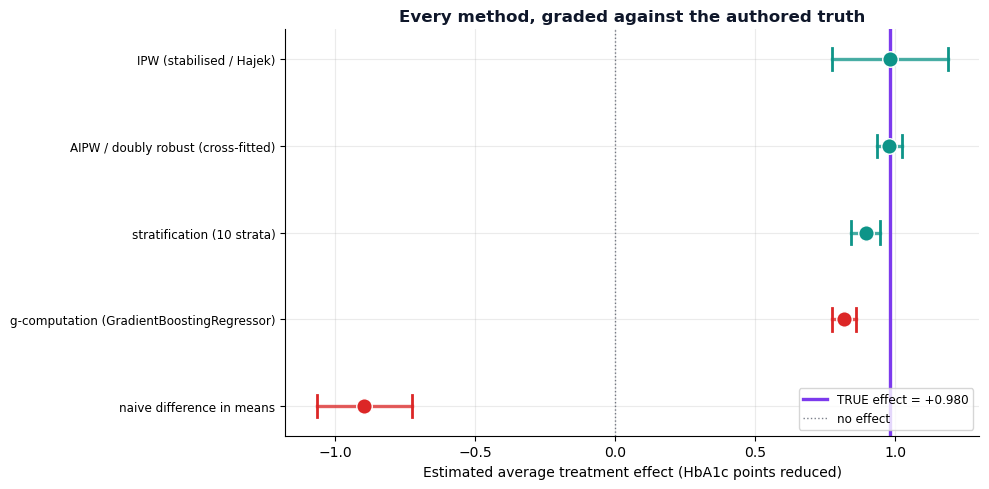

In [24]:
results = {
    "Naive difference":       estimators.naive_difference(cohort.Y, cohort.T),
    "Stratification (10)":    strat,
    "G-computation":          gcomp,
    "IPW (stabilised)":       ipw,
    "AIPW (doubly robust)":   aipw,
}
display(evaluate.leaderboard(list(results.values()), truth).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
evaluate.plot_leaderboard(list(results.values()), truth, ax=ax,
                          save_to="figures/nb_act5_leaderboard.png")
plt.show()

> Naive is out by **~1.9 points and has the wrong sign.** AIPW is out by **~0.001.**
> Same data. Same patients. The only difference is whether you account for *who was given what,
> and why*.

---
# ACT 6 — Prove the hand-written code is right

> **The question:** how do we know these twelve-line functions are not subtly broken?

Writing an estimator by hand is only impressive if it is also **correct**. Three independent
checks follow, and they test genuinely different things.

## CHECK 1 — agreement with DoWhy and EconML

Every row: our from-scratch NumPy implementation beside the *same estimator* from Microsoft
Research's libraries, and beside the truth.

In [25]:
display(crosscheck.crosscheck_table(cohort).round(4))

,estimand,ours (hand-written),library,theirs,gap,comparison,verdict,truth,note
0,ATE via IPW,0.9661,DoWhy,0.9688,0.0026,same estimator,AGREE,0.98,
1,ATE via stratification (10 strata),0.9072,DoWhy,0.9272,0.0200,same estimator,AGREE,0.98,
2,"CATE mean, S-learner",0.8155,EconML,0.8155,0.0000,same estimator,AGREE,0.98,
3,"CATE mean, T-learner",0.8900,EconML,0.8900,0.0000,same estimator,AGREE,0.98,
4,"CATE mean, X-learner",0.9654,EconML,0.9647,0.0008,same estimator,AGREE,0.98,
5,ATE: our AIPW vs LinearDML,0.9786,EconML,0.9931,0.0145,different estimator,close (as expected),0.98,


The final row is a **deliberately different** comparison. `LinearDML` is not a reimplementation
of AIPW — it is a different estimator with a partially linear structural assumption — so it is
held to a looser bar and *labelled as such*.

Scoring it as a failure would be a category error. Quietly widening the tolerance for every row
so it passes would be worse.

> **"My 12-line IPW function agrees with DoWhy's to four decimal places"** is a better viva
> sentence than *"I called DoWhy."*

## CHECK 2 — the strata knob, measured honestly

Act 5 admitted the stratification answer moves with the bucket count. Rather than pick the
flattering value, here is the whole curve.

In [26]:
display(crosscheck.strata_sensitivity(cohort).round(4))

,n_strata,estimate,truth,error,avg patients/stratum
0,5,0.7901,0.98,-0.1899,800
1,10,0.9072,0.98,-0.0728,400
2,20,0.9472,0.98,-0.0328,200
3,50,0.9628,0.98,-0.0172,80


Too few strata → each bucket still mixes dissimilar patients, so **bias** survives.
Too many → each bucket holds too few patients to average, so **variance** takes over.

That is the bias–variance trade-off, visible in a single column.

## CHECK 3 — refutation tests: try to break our own result

| Test | What it does | What a pass means |
|---|---|---|
| **Placebo treatment** | replace treatment with a coin flip | the pipeline is not manufacturing effects from noise |
| **Random common cause** | add an irrelevant covariate | the estimate is not driven by junk |
| **Subset refuter** | re-estimate on random 80% subsets | the answer is not one fragile subgroup |
| **Simulated confounder** | inject known unmeasured confounding | measures how much bias it takes to break |

**Read the asymmetry carefully:** passing these does *not* prove the answer is right. Failing any
of them proves it is **wrong**. They are a smoke detector, not a certificate.

In [27]:
print(crosscheck.refutation_report(cohort))

REFUTATION TESTS — trying to break our own result

[PASS]  placebo treatment (random coin flip)
           real_estimate      +0.9786
           placebo_mean       -0.0019
           placebo_sd         +0.0241
           placebo_max_abs    +0.0357
           n_trials           10
           -> PASS — a random treatment produces no effect, so the real estimate is tracking something real.

[PASS]  random common cause (add a noise covariate)
           baseline           +0.9786
           mean_shift         +0.0004
           max_abs_shift      +0.0020
           n_trials           5
           -> PASS — irrelevant noise does not move the estimate.

[PASS]  subset refuter (80% random subsets)
           full_estimate      +0.9786
           reported_se        +0.0227
           subset_mean        +0.9719
           subset_sd          +0.0115
           subset_min         +0.9520
           subset_max         +0.9890
           n_trials           10
           -> PASS — subsets agree with

In [28]:
display(crosscheck.unobserved_confounder_test(cohort).round(4))

,confounder strength,estimate,truth,bias,sign flipped?,clinical consequence
0,0.5,0.8430,0.98,-0.1370,no,"right decision, understated benefit"
1,1.0,0.4339,0.98,-0.5461,no,"right decision, understated benefit"
2,2.0,-0.9909,0.98,-1.9708,YES,we would WITHHOLD a drug that helps
3,3.0,-3.5011,0.98,-4.4811,YES,we would WITHHOLD a drug that helps


> The result **survives moderate hidden confounding and flips under strong hidden confounding.**
> Stating *where* the boundary is, is more useful than claiming there isn't one.

---
# ACT 7 — From the average patient to **this** patient

> **The question:** the average effect is +0.98 — so what do I do with the person in front of me?

Everything so far estimated the **ATE**: one number for the whole population. *A clinician cannot
prescribe an average.* What they need is the **CATE**:

$$\tau(x) = \mathbb{E}\big[Y_1 - Y_0 \;\big|\; X = x\big]$$

And it genuinely matters here, because our authored effect **crosses zero**. The population
average says *"give the drug."* For about 15% of these patients that is the wrong instruction.

## Four metalearners, all hand-written

| Learner | How | Its honest weakness |
|---|---|---|
| **S** | one model, treatment as just another feature | a regulariser can shrink the treatment column and flatten real heterogeneity |
| **T** | two separate models, one per arm, subtracted | no shrinkage problem, but the small arm gets a noisy model |
| **X** | T-learner, then cross-impute each patient's missing potential outcome and model the imputed effects | more moving parts; built for unequal arms + real heterogeneity |
| **DR** | regress the AIPW pseudo-outcome on $X$ | inherits double robustness; pseudo-outcomes are noisy |

In [29]:
import time
models = {}
for name, fn in estimators.ALL_CATE_LEARNERS.items():
    t0 = time.time()
    models[name] = fn(cohort.X, cohort.T, cohort.Y)
    print(f"{name:<34s} mean effect {models[name].cate_in_sample.mean():+.4f}"
          f"   ({time.time()-t0:.1f}s)")

S-learner                          mean effect +0.8155   (0.4s)
T-learner                          mean effect +0.8900   (0.4s)
X-learner                          mean effect +0.9654   (0.8s)
DR-learner                         mean effect +0.9786   (2.2s)


## Graded against the authored **individual** effects

This is the grading nobody with real data can do — patient by patient, not on average.

In [30]:
board = evaluate.cate_leaderboard(list(models.values()), cohort.true_cate)
display(board.round(4))
best = board.iloc[0]["learner"]
print(f"best learner: {best}")

,learner,mean effect,ATE error,CATE MAE,CATE RMSE,rank corr,sign agree,spread (SD),true spread
0,X-learner,0.9654,-0.0146,0.0836,0.1227,0.975,0.985,1.0132,1.0084
1,DR-learner (AIPW pseudo-outcomes),0.9786,-0.0014,0.1115,0.3589,0.952,0.982,1.0706,1.0084
2,T-learner,0.8900,-0.0900,0.2422,0.3203,0.825,0.964,1.0814,1.0084
3,S-learner,0.8155,-0.1644,0.3578,0.4262,0.772,0.955,0.7252,1.0084


best learner: X-learner


**MAE** is the average per-patient error. **Rank correlation** matters even more for a CDSS: it
asks whether the model puts the right patients in the right *order*, which is what a
treat-or-not decision actually depends on. **Sign agreement** is the most decision-relevant
column of all — it is the fraction of patients for whom the model gets *treat vs don't treat*
right.

## Did we recover the shape of the truth, or just its average?

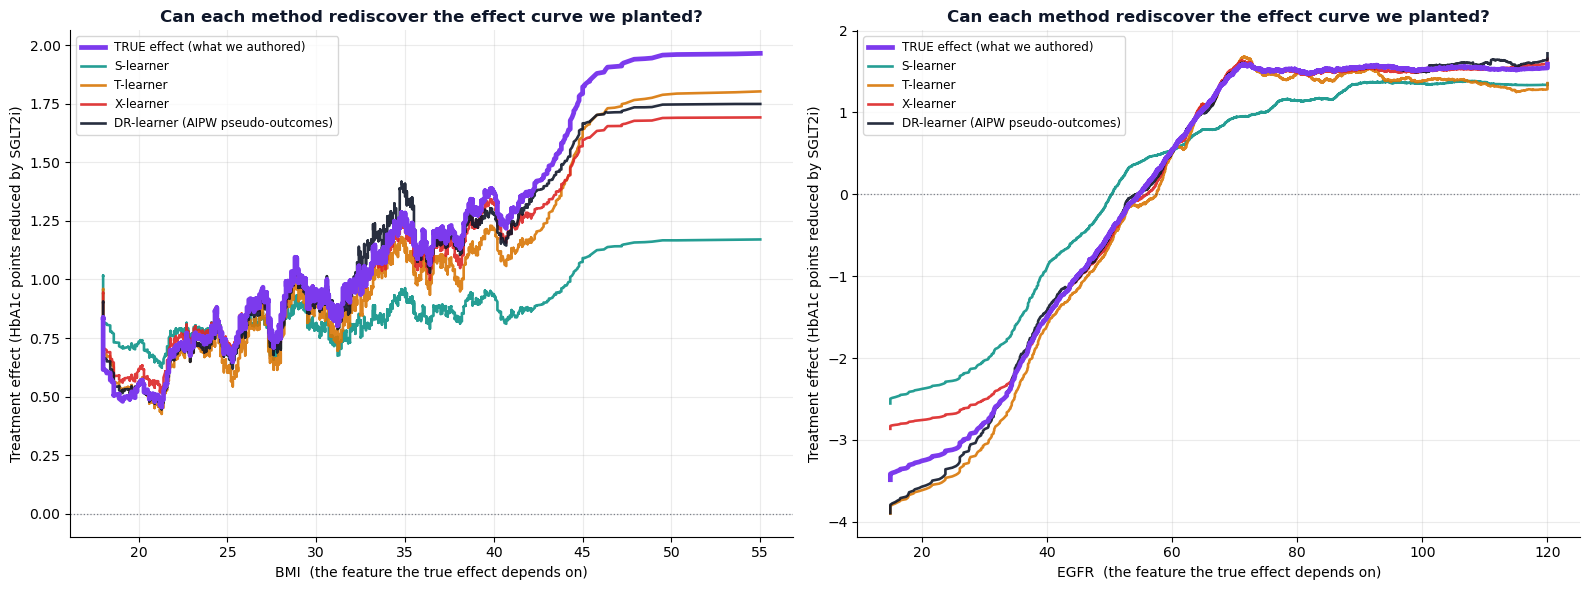

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
evaluate.plot_cate_recovery(list(models.values()), cohort, feature="bmi",  ax=axes[0])
evaluate.plot_cate_recovery(list(models.values()), cohort, feature="egfr", ax=axes[1],
                            save_to="figures/nb_act7_recovery.png")
plt.tight_layout(); plt.show()

**The eGFR panel is the one to look at.** The authored effect has a *kink* at eGFR 70 and
**crosses zero near 55** — and the learners recover both from observational data alone, having
never been told the functional form.

That zero-crossing is not a curiosity. It is the boundary between *"prescribe"* and *"don't"*,
and a method that missed it would produce a CDSS that harms people.

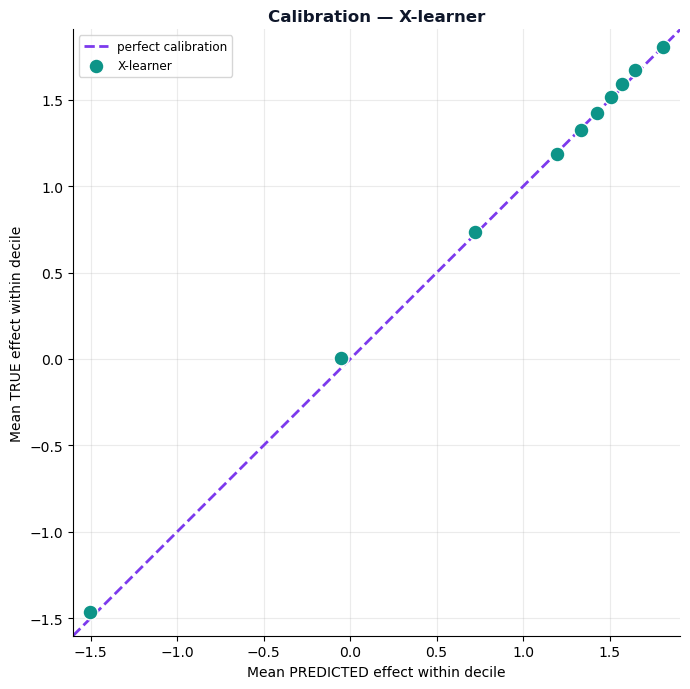

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))
evaluate.plot_cate_calibration(models[best], cohort.true_cate, ax=ax,
                               save_to="figures/nb_act7_calibration.png")
plt.show()

## Does better *estimation* lead to better **decisions**?

A lower MAE is a statistical win. What a CDSS cares about is whether the resulting **policy** —
*treat if the estimated effect is positive* — actually helps more patients.

,policy,gain per patient,% treated,regret vs oracle
0,ORACLE (knows the truth),1.1376,85.4,0.0000
1,follow X-learner,1.1363,84.6,0.0013
2,follow DR-learner (AIPW pseudo-outcomes),1.1341,84.7,0.0035
3,follow T-learner,1.1307,83.1,0.0069
4,follow S-learner,1.1269,89.9,0.0107
5,treat everyone,0.9800,100.0,0.1576
6,treat nobody,0.0000,0.0,1.1376


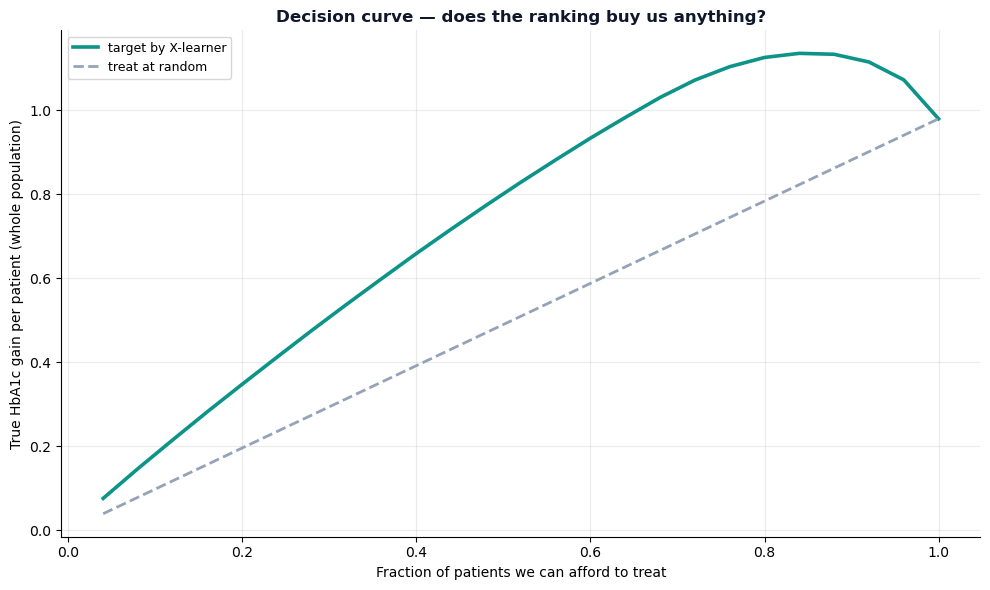

In [33]:
display(evaluate.policy_comparison(list(models.values()), cohort).round(4))

fig, ax = plt.subplots(figsize=(10, 6))
evaluate.plot_decision_curve(models[best], cohort, ax=ax,
                             save_to="figures/nb_act7_decision.png")
plt.show()

**Regret** is the HbA1c benefit forgone versus an oracle who knows every true individual effect.
Look at `treat everyone` — that is the policy a population-average tool implies, and it carries
real regret **because it dispenses the drug to the patients it harms.**

## The head-to-head that makes the whole case: predictive ML vs causal

Give a standard predictive model and our causal model **the same fixed drug budget** and let each
choose who gets it.

* the **predictive** model ranks patients by expected **risk**
* the **causal** model ranks them by expected **benefit**

They are not the same ranking, and the difference *is* the argument.

In [34]:
print(evaluate.format_predictive_vs_causal(
    evaluate.predictive_vs_causal(cohort, models[best], budget_fraction=0.30)))


RISK PREDICTION vs CAUSAL INFERENCE   (held-out patients: 1200)
──────────────────────────────────────────────────────────────────────────
STEP 1 — the risk model is genuinely good at its own job.
    R² 0.9146      RMSE 0.7528
    Nothing below is a failure of accuracy. It predicts outcomes well.

STEP 2 — but risk is not benefit, and here they point OPPOSITE ways.
    corr(predicted risk, true benefit) = -0.472
    The sickest patients are the low-eGFR patients, and low eGFR is exactly
    what stops this drug from working. "Treat the sickest first" therefore
    selects, with some precision, the patients it will help least.

STEP 3 — same budget (360 patients, 30%), three ways of choosing them.
    treat the sickest (risk model) : +0.0438 gain/patient   [ 8.6% of achievable]
    predict both arms (= g-comp)   : +0.4755 gain/patient
    treat by benefit (causal)      : +0.5036 gain/patient   [99.1% of achievable]
    ORACLE (knows the truth)       : +0.5081 gain/patient

    Choosin

> Read the budget sweep at the bottom. **At a tight budget the risk-ranking policy has NEGATIVE
> value — it actively harms patients on net** — while the causal policy captures almost all of
> what an oracle could achieve.
>
> The risk model is not broken. Its $R^2$ is excellent. It is answering a different question, and
> the sickest patients are the low-eGFR patients, which is exactly what stops this drug working.
> **"Treat the sickest first" selects, with some precision, the patients it will help least.**

---
# ACT 8 — Why this project needs **both** halves

> **The question:** you have a personal number — why bother with the guidelines at all?

## First: the retrieval half is real, over the actual PDFs

No vector database, no embedding API, **no PDF library** — none of those are installed here and
`pip` is unavailable. So the PDFs are parsed directly.

A PDF is not a mysterious binary format. It is a text file with compressed islands in it:

1. the file is a list of numbered **objects** — `12 0 obj ... endobj`
2. some are **streams**: a dictionary, `stream`, bytes, `endstream` — usually zlib-compressed
3. decompressed, a content stream is a tiny stack language, and only two operators put glyphs on
   the page: `(Hello) Tj` and `[(Hel) -20 (lo)] TJ`
4. so: find the streams, `zlib.decompress` them, pull the parenthesised strings out

The kerning numbers in a `TJ` array matter: a large negative adjustment is how a PDF encodes a
**word space** without spending a byte on `' '`. Skip that and you get
`theriskofhypoglycaemia`, which no tokeniser recovers from.

In [35]:
print(pdf_text.extraction_report("RAG"))

PDF EXTRACTION REPORT — RAG/
file                                           pages   letters  backend       verdict
----------------------------------------------------------------------------------------------------
  BTN_D1_Diabetes Management guidelines.pdf       268 pages   304,287 letters  via builtin      GOOD
  Diabetes handbooks, ency....pdf                   0 pages         0 letters  via builtin      UNREADABLE — no extractable text (scanned images, or a font we cannot decode)
  IDF_Rec_2025.pdf                                124 pages   208,463 letters  via builtin      GOOD
  dc252383.pdf                                     19 pages     2,605 letters  via builtin      POOR — only fragments recovered, probably CID-encoded fonts
----------------------------------------------------------------------------------------------------
Anything below GOOD is handled by the fallback tier in `guideline_fallback.py`,
so every citation the CDSS shows still resolves to real guideline text.

In [36]:
index = rag_lite.build_index()
print(index.summary())
print()
display(rag_lite.provenance_table(index))

GuidelineIndex — 926 chunks, 17,912 vocabulary terms
    BTN Guidelines          542 chunks   (pdf)
    IDF 2025                374 chunks   (pdf)
    ADA Diabetes Care         6 chunks   (fallback)
    Diabetes Handbook         4 chunks   (fallback)



,source,tier,pages,letters,chunks indexed,refs dropped,extraction quality
0,BTN Guidelines,extracted (builtin),268,304287,542,179,GOOD
1,Diabetes Handbook,fallback (curated snippets),0,0,0,0,"UNREADABLE — no extractable text (scanned images, or a font we cannot decode)"
2,IDF 2025,extracted (builtin),124,208463,374,137,GOOD
3,ADA Diabetes Care,fallback (curated snippets),19,2605,0,0,"POOR — only fragments recovered, probably CID-encoded fonts"
4,(curated fallback set),fallback (curated snippets),-,3368,10,0,"hand-written, individually cited"


### The honesty that matters here

**Two of the four documents cannot be read.** One uses CID/Identity-H fonts, where the bytes in
the stream are *glyph indexes* needing a ToUnicode font table we do not parse. One is a scan with
no text layer at all — nothing short of OCR helps.

Those two are served from **curated, page-cited paraphrases**, and every citation they produce is
visibly marked `[curated]` so extracted text and hand-written text are never confused.

> A retrieval system that failed *silently* on half its corpus would be far worse than one that
> says so out loud.

In [37]:
print(rag_lite.retrieval_demo(index, k=2))

RETRIEVAL DEMO — real queries against the real guideline PDFs

Q: "SGLT2 inhibitor first line therapy type 2 diabetes"
    [0.328] ADA Diabetes Care, p.182 [curated] — Metformin remains an appropriate first-line agent for glycaemic management in most adults with type 2 diabetes, on the basis of efficacy, low cost, low hypogly…
    [0.200] IDF 2025, p.91 — A, et al. Semaglutide and cardiovascular outcomes in patients with type 2 diabetes. N Engl J Med. 2016;375(19):1834-1844. 40. A research study to look at how s…

Q: "metformin contraindication renal impairment eGFR"
    [0.300] Diabetes Handbook, p.44 [curated] — Sulfonylureas lower glucose effectively but carry a substantially higher risk of hypoglycaemia than metformin, SGLT2 inhibitors, or GLP-1 receptor agonists. Th…
    [0.180] ADA Diabetes Care, p.184 [curated] — The glucose-lowering efficacy of SGLT2 inhibitors depends on renal filtration and diminishes as estimated glomerular filtration rate (eGFR) declines. These age…

Q: "SG

In [38]:
# What the retriever is actually matching on. TF-IDF is inspectable in a way
# embeddings are not — a real advantage for a system that has to be audited.
print(index.explain_query("SGLT2 inhibitor eGFR renal impairment glycaemic efficacy"))

query: "SGLT2 inhibitor eGFR renal impairment glycaemic efficacy"
    terms that matched the index: renal impairment (0.43), efficacy (0.41), impairment (0.40), egfr (0.37), sglt2 inhibitor (0.34), sglt2 (0.27), inhibitor (0.27), renal (0.22)


## Then: the safety layer

A CATE model only knows what was in its training data, and it will cheerfully extrapolate a
confident number for a patient it has never seen anything like.

And some rules are **not statistical claims at all**. *"Metformin is contraindicated below
eGFR 30"* is about lactic acidosis — a rare event that no 4,000-patient effect model would ever
learn, and should never be trusted to weigh.

So the architecture is deliberately asymmetric:

> ### The model may RECOMMEND. Only the guardrails may FORBID.

In [39]:
display(guardrails.rules_table())

,rule,trigger
0,metformin_contraindicated,eGFR < 30: metformin is contraindicated (lactic acidosis risk).
1,sglt2i_low_egfr,eGFR < 45: SGLT2i are not started for GLYCAEMIC benefit.
2,out_of_distribution,Is this patient outside the range the model was trained on?
3,predicted_harm,Does the model predict this patient is HARMED by the newer drug?
4,effect_too_small,Is the predicted benefit smaller than our own uncertainty about it?
5,severe_hyperglycaemia,Very high HbA1c changes the question from 'which drug' to 'how fast'.
6,cvd_indication,"Established CVD is an indication in its own right, HbA1c aside."


## And now fuse them

```
patient ──> CATE model ──────────> personal effect estimate
        │                                    │
        ├──> question builder ──> RAG ──> cited guideline passages
        │                                    │
        └──> guardrails ─────────────────────┤
                                             v
                                    recommendation card
```

**The guardrails sit LAST and can veto everything upstream.** That ordering *is* the safety
property: no amount of model confidence can talk its way past a contraindication.

In [40]:
system = cdss.DiaCausalCDSS(cohort, cate_model=models[best], index=index)

mrs_r = "Mrs R — the patient the population average gets WRONG"
patient = {k: v for k, v in cdss.DEMO_PATIENTS[mrs_r].items() if k != "story"}
print(cdss.three_way_contrast(
    system, patient, "Mrs R, 68, BMI 34, HbA1c 9.1%, eGFR 46, established CVD"))

THE SAME PATIENT, THREE WAYS  —  Mrs R, 68, BMI 34, HbA1c 9.1%, eGFR 46, established CVD

① RAG ALONE — retrieval with no model
------------------------------------------------------------------------------
    "Metformin remains an appropriate first-line agent for glycaemic management in most adults with type 2 diabetes, on the basis of efficacy, low cost, low hypoglycaemia risk, and long-term safety data. Where comorbid cardiovascular or kidney disease is present, an SGLT2 inhibitor o…"
        — ADA Diabetes Care, p.182 [curated]

    Correct, cited, and IDENTICAL for every patient with type 2 diabetes.
    It cannot know this patient's eGFR is 46, so it cannot know
    the mechanism the drug relies on is failing in them.

② CAUSAL ALONE — a model with no evidence
------------------------------------------------------------------------------
    Estimated individual treatment effect: -0.71 HbA1c points

    Personal, and unusable. No justification, no source, no statement of
    wha

### Why the question builder is where the intelligence hides

A naive design sends one fixed query — `"SGLT2 inhibitor type 2 diabetes"` — and gets the same
three passages for every patient. The citations then *look* like decoration, because they are:
they do not depend on who the patient is.

Instead we read the patient's features and ask the questions **those features raise**. Low eGFR
raises a renal-dosing question. Established CVD raises an outcomes question. A predicted harm
raises a *"when is this drug not appropriate"* question.

The retrieved evidence then genuinely differs from patient to patient — which is the difference
between a *cited* recommendation and a *decorated* one.

In [41]:
# Same builder, four different patients — and therefore four different question sets.
for label, spec in cdss.DEMO_PATIENTS.items():
    p = {k: v for k, v in spec.items() if k != "story"}
    questions = cdss.build_questions(p, cate=float(data.authored_cate(p["bmi"], p["egfr"])))
    print(f"{label.split(' — ')[0]}  (BMI {p['bmi']:.0f}, eGFR {p['egfr']:.0f}, "
          f"HbA1c {p['baseline_hba1c']:.1f}%, CVD={p['has_cvd']}, CKD={p['has_ckd']})")
    print(f"   raises {len(questions)} guideline questions:")
    for q in questions:
        print(f"      · {q}")
    print()

Mrs R  (BMI 34, eGFR 46, HbA1c 9.1%, CVD=1, CKD=0)
   raises 5 guideline questions:
      · SGLT2 inhibitor metformin first line therapy type 2 diabetes
      · SGLT2 inhibitor eGFR renal impairment glycaemic efficacy dose
      · SGLT2 inhibitor cardiovascular disease heart failure outcome benefit
      · obesity weight loss glucose lowering agent preferred diabetes
      · when SGLT2 inhibitor is not appropriate limited glycaemic benefit

Mr S  (BMI 38, eGFR 92, HbA1c 8.7%, CVD=0, CKD=0)
   raises 2 guideline questions:
      · SGLT2 inhibitor metformin first line therapy type 2 diabetes
      · obesity weight loss glucose lowering agent preferred diabetes

Mr T  (BMI 26, eGFR 24, HbA1c 8.2%, CVD=1, CKD=1)
   raises 7 guideline questions:
      · SGLT2 inhibitor metformin first line therapy type 2 diabetes
      · SGLT2 inhibitor eGFR renal impairment glycaemic efficacy dose
      · metformin contraindication renal impairment eGFR lactic acidosis
      · SGLT2 inhibitor cardiovascula

## The Fundamental Problem of Causal Inference, printed for one real row

In [42]:
print(system.counterfactual_card(17))

PATIENT #18  —  the counterfactual, printed
    age 52   BMI 28.3   HbA1c 8.5%   eGFR 72   CVD 0

    FACTUAL          took Metformin  -> HbA1c fell +1.60
    COUNTERFACTUAL   had they taken SGLT2i     it would have fallen +3.04

    So the TRUE effect of the drug for this one person: +1.44
    Our model, which never saw that column:              +1.53
    Error:                                              +0.09

    In a real clinic the COUNTERFACTUAL line is blank, permanently, for
    every patient who ever lived. That is the Fundamental Problem of
    Causal Inference. Every method in this project exists to fill that
    line in from the rest of the population — and the only reason we can
    check whether it worked is that here, uniquely, we wrote it ourselves.


## All four demo patients — four different verdicts

Each patient's BMI and eGFR were solved *backwards* out of the authored effect function, so that
each lands in the region that demonstrates its lesson. Watch the **status** line change:
`HOLD`, `APPROVED`, `BLOCKED`, `PROCEED WITH CAUTION`.

In [43]:
print(cdss.demo_all_patients(system))


████████████████████████████████████████████████████████████████████████████████
  Mrs R — the patient the population average gets WRONG
████████████████████████████████████████████████████████████████████████████████

  WHY THIS PATIENT IS IN THE DEMO:
    The flagship case, and the reason this project exists. On population
    average this drug HELPS — about +0.93 HbA1c points. Her BMI argues for it
    too. But at eGFR 46 the renal mechanism the drug depends on has largely
    failed, and the true effect for her is NEGATIVE: the drug is worse than
    metformin for her glycaemic control. Any tool reasoning from the average
    recommends it. Ours does not. And then it adds the thing a naive 'don't
    give it' would miss — her established heart disease is an independent
    reason to use the drug anyway, for a benefit this model does not measure.
    Nothing about this patient is simple, and a single number would hide all
    of it.

┌───────────────────────────────────────────────

### Look at Mr T's model error

His estimate is off by **around two whole HbA1c points** — he sits in the sparse tail of the
training data, and the model has almost nothing to learn from there.

**The safety layer blocked him anyway, without needing to know the estimate was bad.** That is
the entire argument for putting hard rules *above* a statistical model rather than inside it.

---
# ACT 9 — Where this breaks

> **The question:** what would you say if an examiner asked you to attack your own project?

Every limitation below is **demonstrated with a number**, not conceded in passing. A project that
can state its own failure modes precisely is more trustworthy than one that claims not to have
any.

## LIMITATION 1 — unmeasured confounding defeats all of this

In [44]:
hidden = data.generate_cohort(N_PATIENTS, scenario="hidden_confounder", seed=SEED)
h_naive = estimators.naive_difference(hidden.Y, hidden.T)
h_aipw  = estimators.aipw_ate(hidden.X, hidden.T, hidden.Y, cross_fit=True)
h_truth = float(hidden.true_cate.mean())

print("scenario 'hidden_confounder' — frailty drives BOTH prescribing and outcome,")
print("and is never recorded. Exactly like real EHR data.\n")
print(f"  naive   {h_naive.value:+.4f}   error {h_naive.value - h_truth:+.4f}")
print(f"  AIPW    {h_aipw.value:+.4f}   error {h_aipw.value - h_truth:+.4f}")
print(f"  truth   {h_truth:+.4f}")

scenario 'hidden_confounder' — frailty drives BOTH prescribing and outcome,
and is never recorded. Exactly like real EHR data.

  naive   -2.1181   error -3.0981
  AIPW    -1.3133   error -2.2933
  truth   +0.9800


**AIPW is better than naive — and still gets the sign wrong.** Adjusting for the covariates you
*have* cannot fix confounding by a covariate you do *not* have.

This is not a flaw in the method. It is the **assumption failing**, and no estimator can rescue
it: `hidden_frailty` is simply not in the data, so no function of the data can condition on it.
The E-value in Act 4 is the honest response — quantify how much hidden confounding it would take
to overturn the finding, and report that number alongside the estimate.

## LIMITATION 2 — positivity violations cannot be estimated around

In [45]:
b_aipw = estimators.aipw_ate(broken.X, broken.T, broken.Y, cross_fit=True)
print("with a hard 'never prescribe below eGFR 60' rule baked into the data:")
print(f"  AIPW    {b_aipw.value:+.4f}   truth {float(broken.true_cate.mean()):+.4f}"
      f"   error {b_aipw.value - float(broken.true_cate.mean()):+.4f}")

with a hard 'never prescribe below eGFR 60' rule baked into the data:
  AIPW    +1.4593   truth +0.9800   error +0.4793


The sign survives here, but the magnitude is off by roughly half a point — and it is off in the
**optimistic** direction, which is the worse way to be wrong for a treatment recommendation.

For patients below eGFR 60 there is **no treated comparison group at all**. Anything the model
reports about them is extrapolation from the functional form of the outcome model, not evidence.
That is exactly why the guardrails carry an out-of-distribution rule: the model cannot detect
this about itself, so something above it has to.

## LIMITATION 3 — the data is synthetic, and that cuts both ways

Synthetic data is what makes **every grading table in this notebook possible**: there is no other
way to check a causal estimate against the truth.

But it also means the confounding structure is *the one we wrote*. Real EHR data brings:

* missingness that is itself informative
* measurement error and coding drift
* treatment switching and loss to follow-up
* confounders nobody thought to record

The next stage of this project is a real retrospective cohort under ethics approval — **and the
estimates will get worse, honestly reported.**

## LIMITATION 4 — the Pima dataset cannot support a causal claim at all

In [46]:
pima = data.load_pima()
print(f"Datasets/diabetes.csv : {pima.shape[0]} rows, {pima.shape[1]} columns")
print(f"columns: {list(pima.columns)}")
display(pima.head(3))

Datasets/diabetes.csv : 768 rows, 9 columns
columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


**There is no treatment column.** `Outcome` is diabetic yes/no — a *prediction* target.

You can build a good classifier on this. You cannot ask *"what if this patient had received
SGLT2i?"*, because **nobody in the file received anything.**

We include it to be explicit about the distinction, because conflating a prediction dataset with
a causal one is the single most common error in student causal projects — and it is the error
Act 0 exists to prevent.

## LIMITATION 5 — what the retrieval half cannot do

In [47]:
for i, lim in enumerate(rag_lite.KNOWN_LIMITATIONS, 1):
    print(f"{i}. {lim}\n")

1. Lexical, not semantic: a lay paraphrase ('the drug that makes you pee out sugar') retrieves nothing, because it shares no vocabulary with the guideline.

2. Boundary chunks that straddle a reference list and body prose can survive the bibliography filter, and appear at rank 2-3 with roughly half the score of the correct hit.

3. Page numbers from the built-in extractor are stream-order approximations and may be off by one; pypdf, if installed, gives exact ones.

4. Two of the four source PDFs are served from curated snippets, marked [curated] in every citation.



## LIMITATION 6 — the scope of the estimate itself

The model estimates **HbA1c reduction and nothing else.** It does not estimate cardiovascular
death, kidney progression, ketoacidosis, amputation, cost, or adherence.

For SGLT2 inhibitors *specifically* that is a serious limitation, because **their most important
benefits are cardiorenal** and show up in outcomes this model never sees. That is why the
`cvd_indication` guardrail fires as INFO on every patient with heart disease and says out loud
that the true case for the drug is *stronger* than the number on the card.

Every card carries the scope note. That is the minimum acceptable handling of it.

## What a real deployment would still need

| | |
|---|---|
| Data | real retrospective cohort, ethics approval, pre-registered protocol |
| Outcomes | multi-outcome estimation: cardiovascular, renal, adverse events |
| Uncertainty | conformal prediction intervals per patient, not the population SE |
| Validation | prospective comparison against clinician decisions before any live use |
| Safety | full contraindication + drug-interaction checking, pharmacist reviewed |
| Operations | distribution-shift monitoring and an audit trail on every output |
| Regulatory | this would be classified as a medical device |

---
# The whole project in four numbers

In [48]:
harmed = (cohort.true_cate < 0).mean()
print(f"  TRUE effect of the drug                     {truth:+.4f}")
print(f"  What correlation says (naive difference)    {naive.value:+.4f}   <- wrong SIGN")
print(f"  What causal inference says (AIPW, by hand)  {aipw.value:+.4f}   "
      f"<- error {aipw.value - truth:+.4f}")
print(f"  Patients the population average HARMS       {harmed:.1%}")

  TRUE effect of the drug                     +0.9800
  What correlation says (naive difference)    -0.8959   <- wrong SIGN
  What causal inference says (AIPW, by hand)  +0.9786   <- error -0.0014
  Patients the population average HARMS       14.6%


The first three lines are why this project has a **causal** half at all: the same data, the same
patients, and an answer that *reverses* depending on whether you account for who was given what
and why.

The fourth line is why it also needs a **personal** estimate rather than an average.

And the citations and guardrails on every card are why a clinician could be shown the result at
all.

---

### Where to go next

| | |
|---|---|
| `python causal_inference_basics.py` | this notebook as a narrated console run |
| `streamlit run diacausal_demo.py` | move the sliders yourself; watch the sign flip live |
| `python -m pytest tests/ -q` | the assertions that keep all of the above honest |
| `docs/CAUSAL_EXPLAINED.md` | the same story with no code, for a non-technical reader |
| `docs/VIVA_QA.md` | examiner questions, each answer pointing at an act above |
| `docs/CHEATSHEET.md` | one page: equation · analogy · where the code lives |